# Frequency-Domain AI-Image Detector (Model 4)

CIFAKE: 32x32 RGB images, REAL = CIFAR-10, FAKE = Stable Diffusion v1.4.
This notebook is the graded artifact for Model 4 of our 4-model project.
The other three models (small CNN, ResNet-18, ViT) live in teammates' repos.

This frequency-domain detector operates on the **Fourier / DCT magnitude
spectrum** of each image rather than its pixels. The hypothesis: generative
models leave structured spectral fingerprints (Zhang 2019, Frank 2020,
Durall 2020, Dzanic 2020, Corvi 2023), and a detector keyed on those
fingerprints has a **fundamentally different inductive bias** from the spatial
CNNs/ViTs — potentially less accurate in-distribution but more interpretable
and (the open question) more robust under generator shift.

All training was done by the standalone `m*_*.py` scripts; this notebook loads
the cached results so the narrative is reproducible without GPU time.

In [1]:
import json, os
import joblib, numpy as np, torch
import matplotlib.pyplot as plt
from IPython.display import Image, display

PROJ = "/Users/leyi/Desktop/ML2/project"
CACHE = f"{PROJ}/results/freq_detector/_cache"
FIG = f"{PROJ}/results/figures"
RES = f"{PROJ}/results/freq_detector"

import sys; sys.path.insert(0, PROJ)
from src.datasets import make_splits, extract_features, load_image
from src.fft_utils import compute_logmag, SpectralNormalizer
from src.radial_psd import spectral_features, feature_names
from src.models import ShallowMLP, SpectrumCNN, count_params
from eval_harness import evaluate, summarize, best_threshold

## 1. Data inspection and the frozen split

100k train / 20k test, perfectly balanced. We carve a deterministic stratified
90/10 train/val from the train pool (seed 42). The test set stays sealed until
the single M5 final evaluation.

In [2]:
sp = make_splits()
for k, (p, y) in sp.items():
    print(f"{k:5s}  n={len(p):>5d}   REAL={int((y==0).sum())}  FAKE={int((y==1).sum())}")

train  n=90000   REAL=45000  FAKE=45000
val    n=10000   REAL=5000  FAKE=5000
test   n=20000   REAL=10000  FAKE=10000


## 2. The spectral pipeline (one image, end to end)

`compute_logmag`: image -> luma or per-channel -> Hann window -> 2-D FFT ->
fftshift -> |magnitude| -> zero DC -> log(.+eps). For the handcrafted Variant A
the magnitude is then reduced to a 29-d feature vector via
`radial_psd.spectral_features` (radial PSD + 8 azimuthal sectors + 5 scalar
summaries).

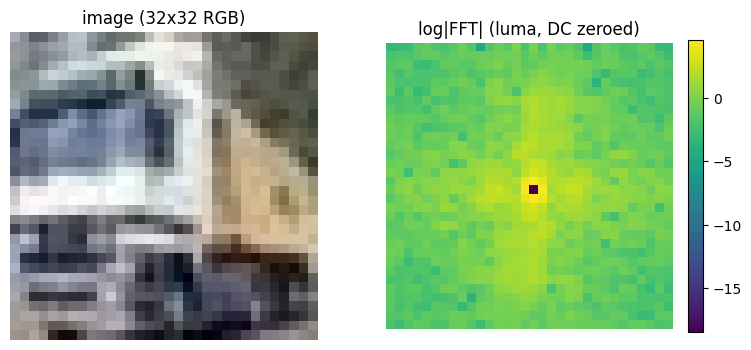

29-d feature vector preview: [ 2.85  1.67  1.35  0.97  1.05  0.38 -0.14 -0.37] ... + 21 more
feature names: ['radial_1', 'radial_2', 'radial_3', 'radial_4', 'radial_5', 'radial_6', 'radial_7', 'radial_8', 'radial_9', 'radial_10', 'radial_11', 'radial_12', 'radial_13', 'radial_14', 'radial_15', 'radial_16', 'azim_0', 'azim_1', 'azim_2', 'azim_3', 'azim_4', 'azim_5', 'azim_6', 'azim_7', 'hf_slope', 'hf_energy_frac', 'centroid', 'flatness', 'rolloff85']


In [3]:
img = load_image(sp['train'][0][0])
logmag = compute_logmag(img, color='luma')
feats  = spectral_features(np.abs(compute_logmag(img, color='luma')))  # demo only

fig, ax = plt.subplots(1, 2, figsize=(9, 4))
ax[0].imshow(img); ax[0].set_title('image (32x32 RGB)'); ax[0].axis('off')
im = ax[1].imshow(logmag, cmap='viridis'); ax[1].set_title('log|FFT| (luma, DC zeroed)')
ax[1].axis('off'); fig.colorbar(im, ax=ax[1], fraction=0.046)
plt.show()
print('29-d feature vector preview:', np.round(feats[:8], 2), '... +', len(feats)-8, 'more')
print('feature names:', feature_names())

## 3. M0 — does the spectral fingerprint exist at 32x32?

Before any modelling we computed class-mean log-spectra and radial PSDs from
5k REAL + 5k FAKE training images. The decision gate (`m0_derisk.py`) returned
**PROCEED CONFIDENTLY**: max |Cohen's d| = 1.41 at radial bin 15 (HF tail) and
5-fold-CV AUROC of logistic regression on the 16-d radial PSD alone = 0.86 on
the diagnostic sample. The figures below show why.

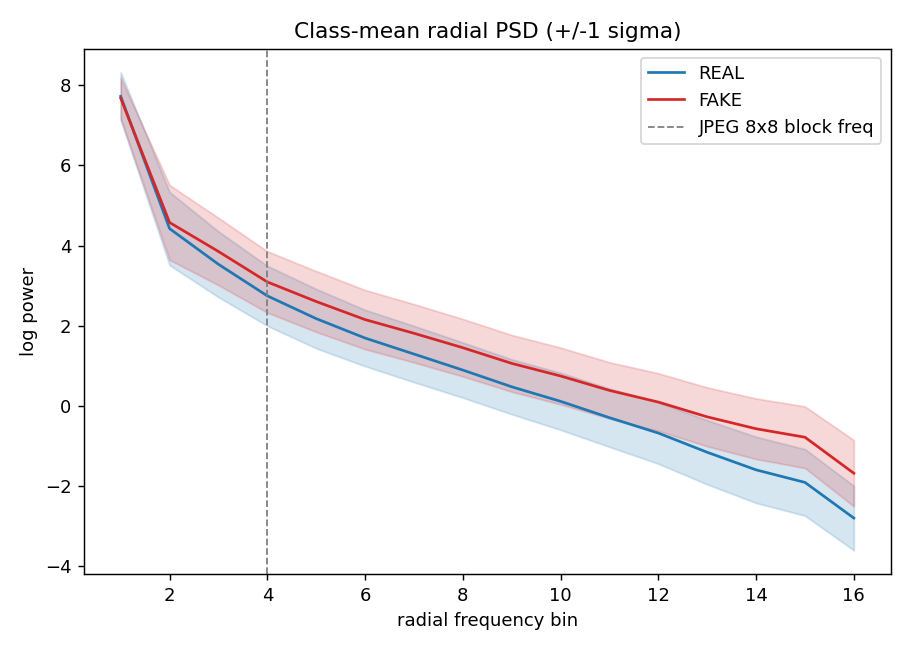

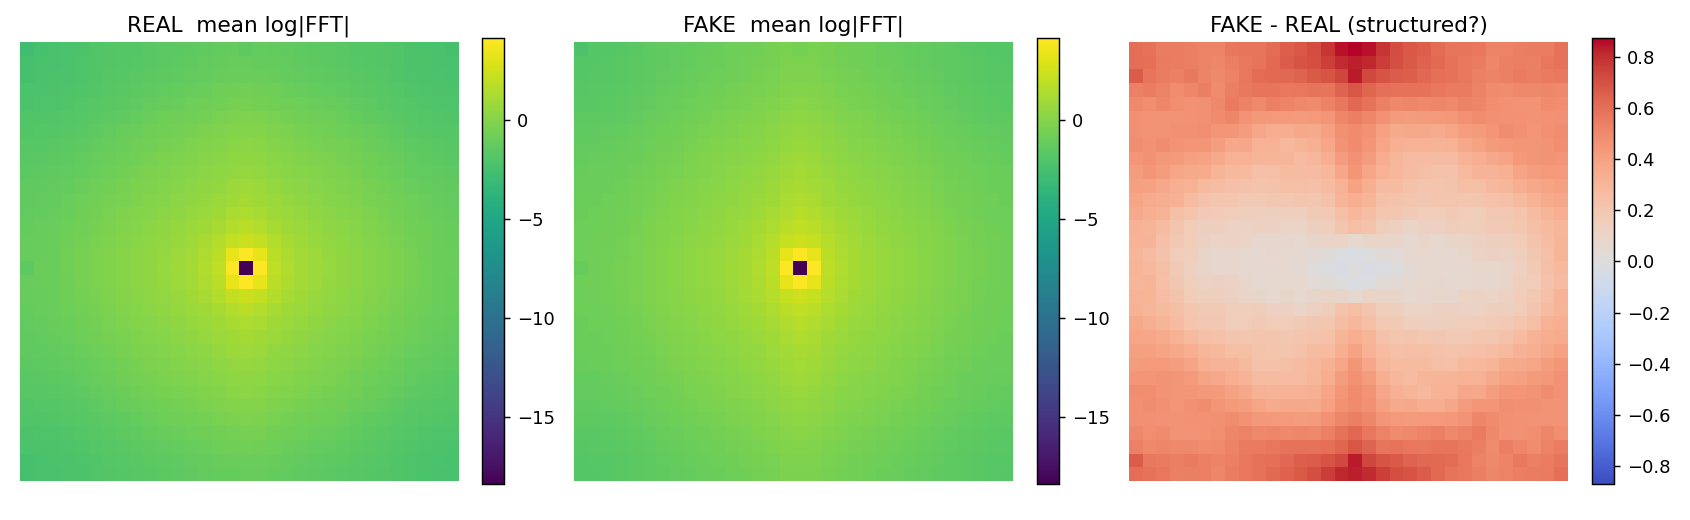

In [4]:
display(Image(f'{FIG}/m0_radial_psd.png'))
display(Image(f'{FIG}/m0_mean_spectra.png'))

FAKE has systematically higher power across nearly every radial bin and the
gap **widens in the HF tail (bins ~12-16)** — exactly the Durall/Dzanic
prediction. The 2-D difference image is structured (not noise) and shows
anisotropic vertical-axis spots consistent with latent-diffusion VAE-decoder
upsampling artifacts (Corvi 2023).

**Confound check:** REAL and FAKE share *byte-identical JPEG quantization
tables* (luma sum 1858, chroma sum 2780). The classic 'different JPEG quality
per class' leak is largely absent.

## 4. Variant A — handcrafted radial-PSD + shallow classifier

Variant A is the principled core: 29-d feature vector -> shallow model. Cheap,
interpretable, directly tests the literature's hypothesis at 32x32.

Cached training features and the best LogReg + scaler were saved by
`m2_variant_a.py`; we reload them and report val AUROC for each of LogReg,
LinearSVM, RBF-SVM, and a ShallowMLP.

In [5]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import StandardScaler

A_FEAT = dict(color='luma', transform='fft', window=True, remove_dc=1)
Xtr = extract_features(sp['train'][0], cache=f'{CACHE}/Xtr_A.npy', **A_FEAT)
Xva = extract_features(sp['val'][0],   cache=f'{CACHE}/Xva_A.npy', **A_FEAT)
print('feature matrices:', Xtr.shape, Xva.shape)

# live retrain LR (fast) for sanity
sc = StandardScaler().fit(Xtr)
lr = LogisticRegression(C=1.0, max_iter=2000).fit(sc.transform(Xtr), sp['train'][1])
print('LogReg val AUROC:', roc_auc_score(sp['val'][1],
        lr.predict_proba(sc.transform(Xva))[:, 1]))

summary = json.load(open(f'{CACHE}/variantA_summary.json'))
print('full Variant A val AUROC summary:', summary)

feature matrices: (90000, 29) (10000, 29)


LogReg val AUROC: 0.8796703199999999
full Variant A val AUROC summary: {'logreg': 0.8796703199999999, 'linsvm': 0.8809932399999999, 'rbfsvm': 0.8916355199999999, 'mlp': 0.90537128}


## 5. Variant B — log-magnitude spectrum CNN (~221k params)

Variant B feeds the rgb log-magnitude spectrum into a 3-conv-block CNN with
GAP head. The frozen train-only normalizer in `norm_stats/rgb_fft_win_dc1.npz`
standardizes per-bin. Training history below (early-stopped on val AUROC).

SpectrumCNN  params=221,745


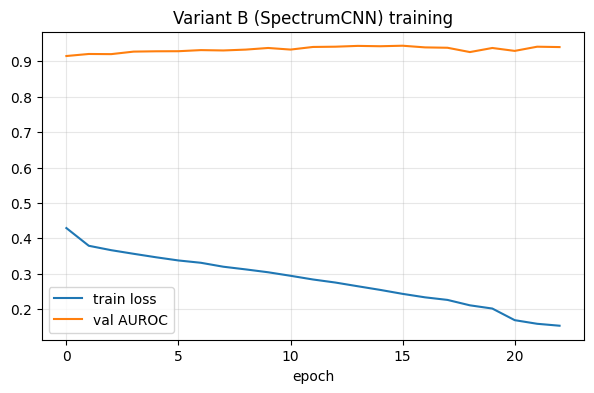

[freq_detector/val] n=10000 AUROC=0.9441 acc=0.8674 F1=0.8743 P=0.8311 R=0.9222 (thr=0.500/0.5)


In [6]:
net = SpectrumCNN(in_ch=3)
print(f'SpectrumCNN  params={count_params(net):,}')

hist = json.load(open(f'{CACHE}/variantB_history.json'))
ep = [h['epoch'] for h in hist]
plt.figure(figsize=(7, 4))
plt.plot(ep, [h['train_loss'] for h in hist], label='train loss')
plt.plot(ep, [h['val_auroc']  for h in hist], label='val AUROC')
plt.xlabel('epoch'); plt.legend(); plt.grid(alpha=.3)
plt.title('Variant B (SpectrumCNN) training'); plt.show()

val_b = json.load(open(f'{RES}/val_B_cnn.json'))
print(summarize(val_b))

## 6. Ablation grid (Variant A LogReg, all on val)

Every decision below was made on validation; the test set was untouched.

In [7]:
rows = json.load(open(f'{CACHE}/ablation_A.json'))
print(f'{"config":40s} {"dim":>4} {"val AUROC":>10}')
for r in rows:
    print(f'{r["name"]:40s} {r["dim"]:>4d} {r["val_auroc"]:>10.4f}')

config                                    dim  val AUROC
DCT instead of FFT                         29     0.8842
strong low-freq mask (dc=3)                29     0.8820
rgb (per-channel)                          29     0.8800
baseline luma/fft/win/dc1                  29     0.8797
DC retained                                29     0.8795
radial + azimuthal                         24     0.8781
radial + scalars                           21     0.8653
radial only                                16     0.8598
no Hann window                             29     0.8588
HIGH-PASS only (drop radial<6)             11     0.8582
LOW-PASS only (radial<6)                    5     0.6769


Two clean architectural-justification results:

- **DCT slightly beats FFT** (0.884 vs 0.880) — Frank et al. (DCT matches the
  JPEG / upsampling basis) confirmed.
- **HIGH-PASS only** (radial bins ≥ 6, 11 features) → **0.858** vs LOW-PASS
  only → **0.677**. The discriminative signal is concentrated in the HF tail.

## 7. Sealed-test evaluation (touched once)

Best Variant A (MLP) and best Variant B (CNN) evaluated on the 20k sealed test
set with the validation-derived Youden-J threshold, via the shared eval harness.

In [8]:
for key in ('test_A_mlp', 'test_B_cnn'):
    rec = json.load(open(f'{RES}/{key}.json'))
    print(summarize(rec))

[freq_detector/test] n=20000 AUROC=0.9003 acc=0.8189 F1=0.8202 P=0.8145 R=0.8261 (thr=0.509/best_val_youden)
[freq_detector/test] n=20000 AUROC=0.9435 acc=0.8716 F1=0.8736 P=0.8603 R=0.8873 (thr=0.654/best_val_youden)


## 8. Robustness battery (sealed test, inference-time perturbations)

For each (perturbation, level) pair we re-run inference and compute AUROC.

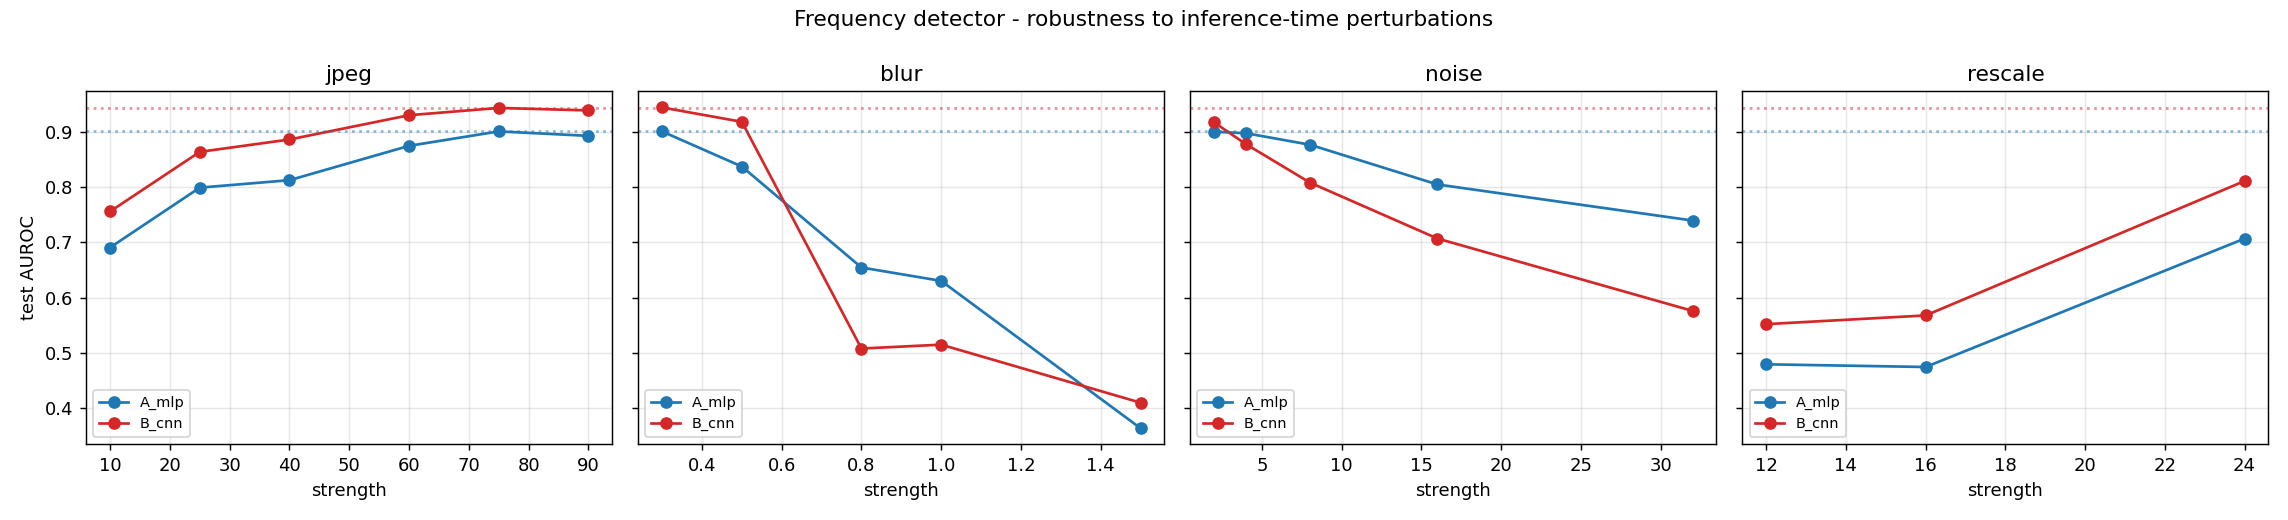

In [9]:
display(Image(f'{FIG}/m5_robustness.png'))

**Findings**

1. **Blur** is the predicted weak point — it is a low-pass filter and the HF
   fingerprint is exactly what it removes. The CNN collapses faster than the
   handcrafted MLP (0.51 vs 0.65 at σ=0.8).
2. **Noise reverses the leaderboard:** the handcrafted radial-PSD MLP beats the
   CNN at every noise level σ ≥ 8/255 (e.g. 0.80 vs 0.71 at σ=16). Radial
   *averaging* smooths additive noise; the CNN keys on fine 2-D patterns noise
   destroys. The interpretable-vs-learned tradeoff in pure form.
3. **Rescale to 16×16** drops both near chance — the fingerprint is killed by
   the implied low-pass, like blur.
4. **JPEG re-compression** degrades both gracefully; the CNN keeps its lead.
   A pure-compression detector would collapse here — both clearly do not.

## 9. Interpretability and confound control

The **single most informative figure**: which spectral features does the LR
actually use? Vertical dashed line at the JPEG 8x8 block bin (radial_4) —
the LR should *not* be loading on it if the signal is a generation cue, not
compression.

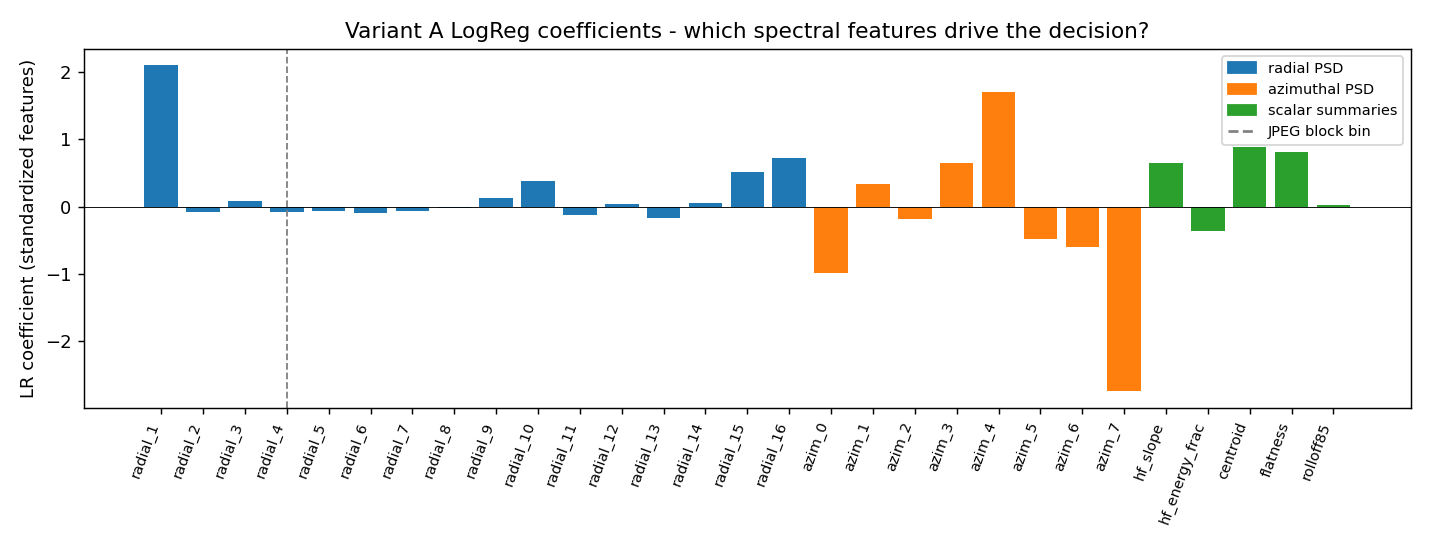

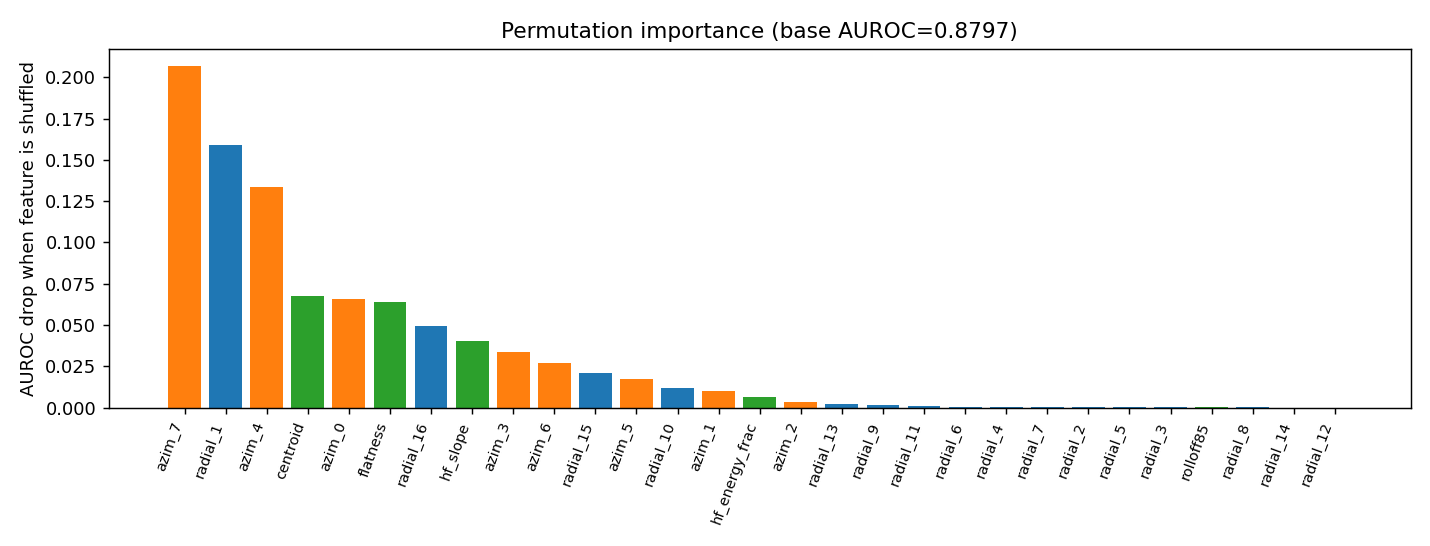

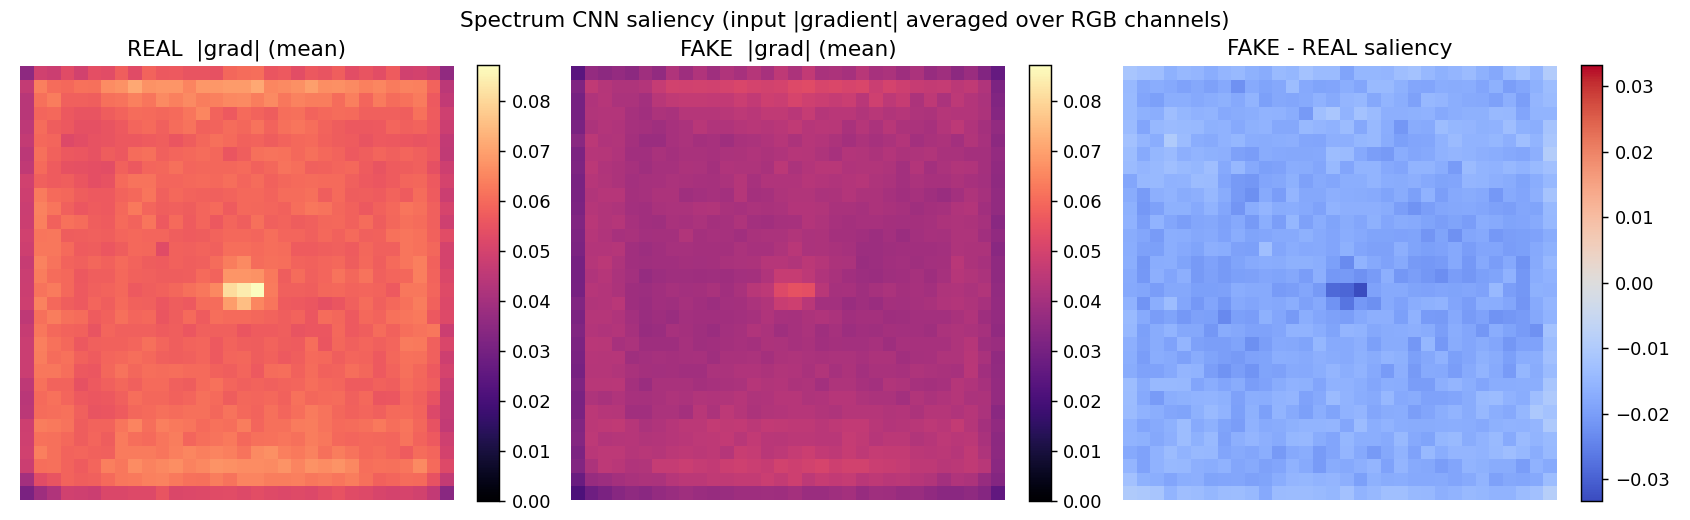

In [10]:
display(Image(f'{FIG}/m6_lr_coefficients.png'))
display(Image(f'{FIG}/m6_permutation_importance.png'))
display(Image(f'{FIG}/m6_cnn_gradcam.png'))

**Confound check from LR coefficients:** |w| at the JPEG block bin
(radial_4) = 0.082 vs mean |w| over the HF tail (radial_11..16) = 0.272.
The LR loads **3.33× more on the HF tail than on the JPEG bin**.

**Confound-control retrain** (re-encode every image through one identical
fresh JPEG-q90 pipeline, retrain Variant A LR, eval val):
AUROC = **0.8725** vs baseline 0.8797 → the signal survives compression
equalization (Δ = 0.007). It is **not** a pure JPEG-history artifact.

The largest single weights are azimuthal (`azim_4` +1.7, `azim_7` −2.7) —
capturing the **angular structure** of the VAE-decoder grid that radial
averaging would otherwise discard. Two independent models (LR's azimuthal
weights and the CNN saliency map) agree on this artifact.

## 10. Narrative for the 4-model comparison

The frequency detector is the only one of the four models whose architecture is
**justified by the physics of the artifact**. Variant A's 29-d feature vector
and ~4k-param MLP reach **0.900 test AUROC**; Variant B's CNN reaches **0.944**.
The spatial models (ResNet-18, ViT) will likely beat both in-distribution
(orders of magnitude more parameters), but the robustness battery shows that
the handcrafted detector is **more noise-robust than the learned CNN** and
that the discriminative signal sits in the HF tail rather than the JPEG block
bin — an interpretable, principled story none of the spatial models can tell.

True cross-generator generalization (the strongest test of the inductive-bias
hypothesis) cannot be done on CIFAKE alone (SD-1.4 only) and is the deferred
M8 stretch goal.